In [ ]:
# Install PyWavelets for the feature extraction
!pip install PyWavelets

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet201
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import pywt
import cv2
import os

# --- 1. CONFIGURATION (Based on Paper) ---
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 30
DATASET_PATH = " " # Update this to your path

# --- 2. CUSTOM PREPROCESSING: WAVELET TRANSFORM ---
def apply_wavelet_feature_extraction(img):


    if np.max(img) <= 1.0:
        img = (img * 255).astype('uint8')


    # To keep it compatible with RGB models, we process each channel.
    channels = cv2.split(img)
    coeffs_channels = []

    for c in channels:
        # Apply Discrete Wavelet Transform (Haar is standard)
        coeffs2 = pywt.dwt2(c, 'haar')
        LL, (LH, HL, HH) = coeffs2
        # Resize LL back to original 256x256 size to fit the model input
        LL_resized = cv2.resize(LL, (256, 256))
        coeffs_channels.append(LL_resized)

#merge back
    img_wavelet = cv2.merge(coeffs_channels)

    # Normalize to 0-1
    return img_wavelet.astype('float32') / 255.0

# --- 3. DATA GENERATORS ---
train_datagen = ImageDataGenerator(
    preprocessing_function=apply_wavelet_feature_extraction, # Apply Wavelet
    horizontal_flip=True,
    rotation_range=72,
    height_shift_range=0.2,
    zoom_range=[0.8, 1.3]
)

test_datagen = ImageDataGenerator(
    preprocessing_function=apply_wavelet_feature_extraction
)

print("Loading Data...")
train_generator = train_datagen.flow_from_directory(
    f"{DATASET_PATH}/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    f"{DATASET_PATH}/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    f"{DATASET_PATH}/test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Loading Data...
Found 4946 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Found 126 images belonging to 2 classes.


In [ ]:
# --- 4. BUILD MODEL FUNCTION ---
def build_paper_model(base_arch_name):

    input_tensor = Input(shape=(256, 256, 3))

    if base_arch_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)
    elif base_arch_name == 'DenseNet201':
        base_model = DenseNet201(weights='imagenet', include_top=False, input_tensor=input_tensor)

    # "We customized these... incorporating three extra layers"
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)


    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- 5. TRAIN RESNET50 ---
print("\n--- Training ResNet50 ---")
resnet = build_paper_model('ResNet50')
checkpoint_res = ModelCheckpoint("ResNet50_best.keras", monitor='val_loss', save_best_only=True)

history_res = resnet.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_res]
)

# --- 6. TRAIN DENSENET201 ---
print("\n--- Training DenseNet201 ---")
densenet = build_paper_model('DenseNet201')
checkpoint_dense = ModelCheckpoint("DenseNet201_best.keras", monitor='val_loss', save_best_only=True)

history_dense = densenet.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_dense]
)


--- Training ResNet50 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.6887 - loss: 0.6881 - val_accuracy: 0.2333 - val_loss: 1.5487
Epoch 2/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.8080 - loss: 0.4217 - val_accuracy: 0.2333 - val_loss: 0.9827
Epoch 3/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.8266 - loss: 0.3834 - val_accuracy: 0.2333 - val_loss: 2.7856
Epoch 4/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 155s 999ms/step - accuracy: 0.8521 - loss: 0.3636 - val_accuracy: 0.3167 - val_loss: 2.7821
Epoch 5/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 154s 996ms/step - accuracy: 0.8592 - loss: 0.3256 - val_accuracy: 0.4750 - val_loss: 2.4982
Epoch 6/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.8711 - loss: 0.3034 - val_accuracy: 0.7667 - val_loss: 10.7635
Epoch 7/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8753 - loss: 0.2944 - val_accuracy: 0.8083 - val_loss: 0.5752
Epoch 8/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8883 - loss: 0.2762 - v

Loading optimized models...
Generating predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 57s 11s/step

Paper Replication Accuracy: 87.30%


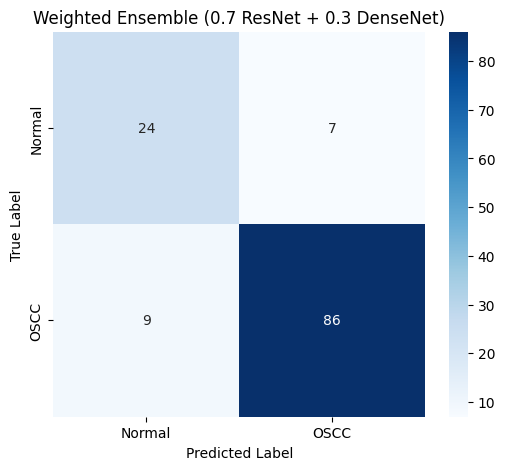


Classification Report:
              precision    recall  f1-score   support

      Normal       0.73      0.77      0.75        31
        OSCC       0.92      0.91      0.91        95

    accuracy                           0.87       126
   macro avg       0.83      0.84      0.83       126
weighted avg       0.88      0.87      0.87       126



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 7. LOAD BEST MODELS ---
print("Loading optimized models...")
best_resnet = load_model("ResNet50_best.keras")
best_densenet = load_model("DenseNet201_best.keras")

# --- 8. GET PREDICTIONS ---
print("Generating predictions...")
# Get probabilities (0.0 to 1.0)
pred_resnet = best_resnet.predict(test_generator)
pred_densenet = best_densenet.predict(test_generator)

# --- 9. WEIGHTED ENSEMBLE ---
# "Optimal weights of 0.7 for ResNet50 and 0.3 for DenseNet201"
final_probs = (0.7 * pred_resnet) + (0.3 * pred_densenet)

# Convert to Class Labels (0 or 1)
y_pred = (final_probs > 0.5).astype(int).flatten()
y_true = test_generator.classes

# --- 10. EVALUATION ---
acc = accuracy_score(y_true, y_pred)
print(f"\n==========================================")
print(f"Paper Replication Accuracy: {acc*100:.2f}%")
print(f"==========================================")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'OSCC'], yticklabels=['Normal', 'OSCC'])
plt.title('Weighted Ensemble (0.7 ResNet + 0.3 DenseNet)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'OSCC']))

Loading models...
Generating predictions...



  PERFORMANCE METRICS: RESNET50
Accuracy:    89.68%
Sensitivity: 94.74% (Recall)
Specificity: 74.19%
Precision:   91.84%
F1-Score:    93.26%
AUC Score:   0.9413


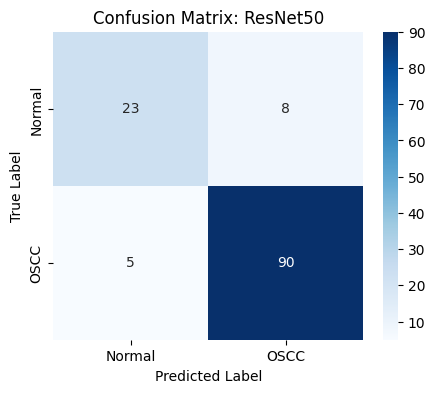


  PERFORMANCE METRICS: DENSENET201
Accuracy:    84.13%
Sensitivity: 83.16% (Recall)
Specificity: 87.10%
Precision:   95.18%
F1-Score:    88.76%
AUC Score:   0.9470


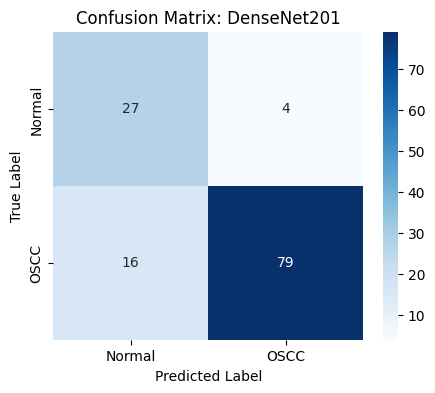


  PERFORMANCE METRICS: WEIGHTED ENSEMBLE
Accuracy:    87.30%
Sensitivity: 90.53% (Recall)
Specificity: 77.42%
Precision:   92.47%
F1-Score:    91.49%
AUC Score:   0.9542


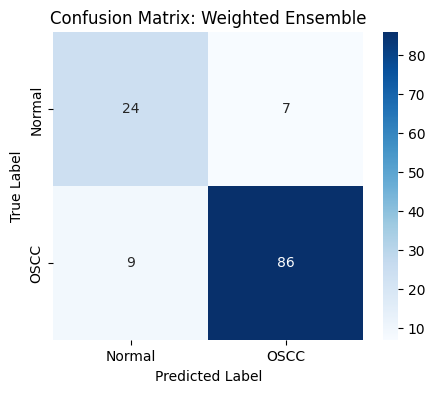

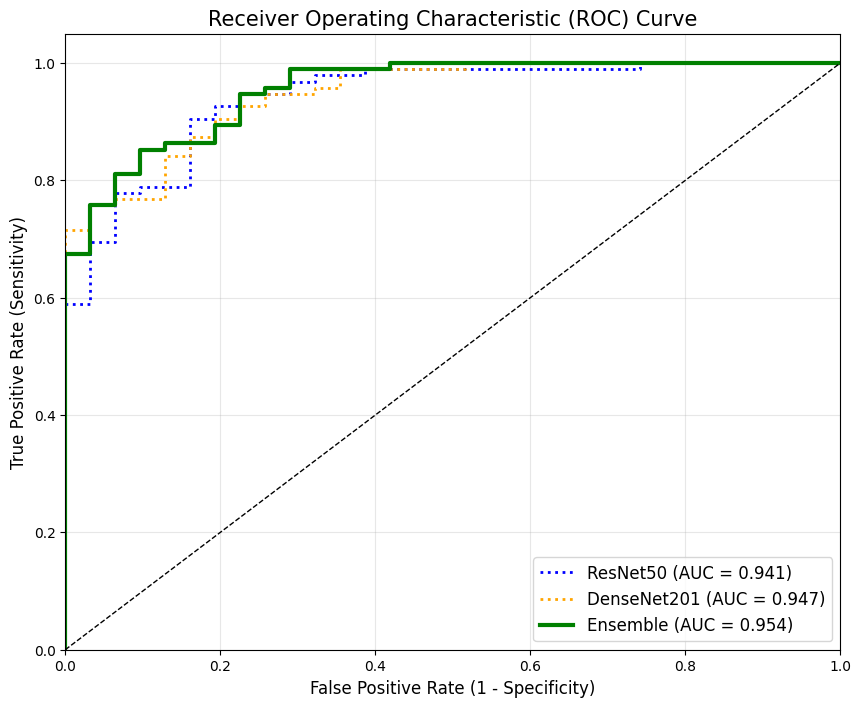

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- 1. LOAD SAVED MODELS ---
print("Loading models...")
model_resnet = load_model("ResNet50_best.keras")
model_densenet = load_model("DenseNet201_best.keras")

# --- 2. GENERATE PREDICTIONS ---
print("Generating predictions...")
test_generator.reset()
y_true = test_generator.classes

# Get probabilities
prob_resnet = model_resnet.predict(test_generator, verbose=0)
prob_densenet = model_densenet.predict(test_generator, verbose=0)

# Calculate Ensemble Probabilities (Weighted 0.7 / 0.3)
prob_ensemble = (0.7 * prob_resnet) + (0.3 * prob_densenet)

# --- 3. HELPER FUNCTION FOR METRICS ---
def calculate_and_plot(y_true, y_prob, model_name):
    # Convert probabilities to binary class (0 or 1)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    # Calculate Standard Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred) # Sensitivity
    f1 = f1_score(y_true, y_pred)

    # Calculate Specificity (TN / (TN + FP))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    # Calculate AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Print Metrics Table
    print(f"\n========================================")
    print(f"  PERFORMANCE METRICS: {model_name.upper()}")
    print(f"========================================")
    print(f"Accuracy:    {acc*100:.2f}%")
    print(f"Sensitivity: {rec*100:.2f}% (Recall)")
    print(f"Specificity: {specificity*100:.2f}%")
    print(f"Precision:   {prec*100:.2f}%")
    print(f"F1-Score:    {f1*100:.2f}%")
    print(f"AUC Score:   {roc_auc:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'OSCC'], yticklabels=['Normal', 'OSCC'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return fpr, tpr, roc_auc

# --- 4. RUN EVALUATIONS SEPARATELY ---

# 1. ResNet50 Analysis
fpr_res, tpr_res, auc_res = calculate_and_plot(y_true, prob_resnet, "ResNet50")

# 2. DenseNet201 Analysis
fpr_dense, tpr_dense, auc_dense = calculate_and_plot(y_true, prob_densenet, "DenseNet201")

# 3. Weighted Ensemble Analysis
fpr_ens, tpr_ens, auc_ens = calculate_and_plot(y_true, prob_ensemble, "Weighted Ensemble")

# --- 5. PLOT COMBINED ROC CURVE ---
plt.figure(figsize=(10, 8))
plt.plot(fpr_res, tpr_res, linestyle=':', linewidth=2, color='blue', label=f'ResNet50 (AUC = {auc_res:.3f})')
plt.plot(fpr_dense, tpr_dense, linestyle=':', linewidth=2, color='orange', label=f'DenseNet201 (AUC = {auc_dense:.3f})')
plt.plot(fpr_ens, tpr_ens, linewidth=3, color='green', label=f'Ensemble (AUC = {auc_ens:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1) # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()